In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [2]:
data=pd.read_csv('AMZN.csv')

In [6]:
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
6511,2023-03-30,101.550003,103.040001,101.010002,102.000000,102.000000,53633400
6512,2023-03-31,102.160004,103.489998,101.949997,103.290001,103.290001,56704300
6513,2023-04-03,102.300003,103.290001,101.430000,102.410004,102.410004,41135700
6514,2023-04-04,102.750000,104.199997,102.110001,103.949997,103.949997,48662500
6515,2023-04-05,103.910004,103.910004,100.750000,101.099998,101.099998,45103000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6516 entries, 0 to 6515
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6516 non-null   object 
 1   Open       6516 non-null   float64
 2   High       6516 non-null   float64
 3   Low        6516 non-null   float64
 4   Close      6516 non-null   float64
 5   Adj Close  6516 non-null   float64
 6   Volume     6516 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 356.5+ KB


In [7]:
data=data[['Date','Close']]
data

,Date,Close
0,1997-05-15,0.097917
1,1997-05-16,0.086458
2,1997-05-19,0.085417
3,1997-05-20,0.081771
4,1997-05-21,0.071354
...,...,...
6511,2023-03-30,102.000000
6512,2023-03-31,103.290001
6513,2023-04-03,102.410004
6514,2023-04-04,103.949997


In [36]:
device='cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

C:\Users\RAHUL\AppData\Local\Temp\ipykernel_34016\3179286227.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Date']=pd.to_datetime(data['Date'])


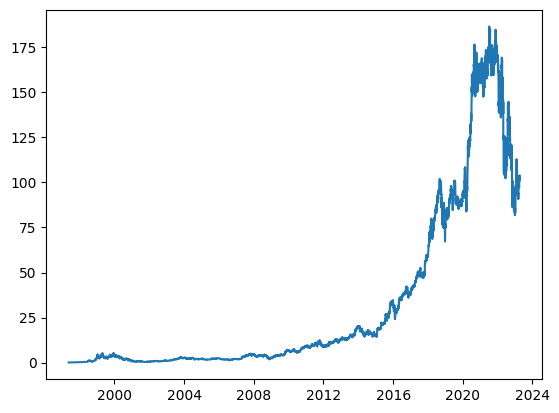

In [9]:
data['Date']=pd.to_datetime(data['Date'])
plt.plot(data['Date'],data['Close'])

In [14]:
from copy import deepcopy as dc

def dataframe_lstm(df,n_steps):
    df=dc(df)
    df['Date']=pd.to_datetime(df['Date'])
    df.set_index('Date',inplace=True)

    for i in range(1,n_steps+1):
        df[f'Close(t-{i})']=df['Close'].shift(i)
    
    df.dropna(inplace=True)
    return df

lookback=7
shifted_df=dataframe_lstm(data,lookback)
shifted_df.head()

,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
1997-05-27,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458,0.097917
1997-05-28,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458
1997-05-29,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417
1997-05-30,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771
1997-06-02,0.075521,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354


In [15]:
shifted_df_np=shifted_df.to_numpy()
shifted_df_np

array([[7.91670000e-02, 7.50000000e-02, 6.97920000e-02, ...,
        8.54170000e-02, 8.64580000e-02, 9.79170000e-02],
       [7.65630000e-02, 7.91670000e-02, 7.50000000e-02, ...,
        8.17710000e-02, 8.54170000e-02, 8.64580000e-02],
       [7.52600000e-02, 7.65630000e-02, 7.91670000e-02, ...,
        7.13540000e-02, 8.17710000e-02, 8.54170000e-02],
       ...,
       [1.02410004e+02, 1.03290001e+02, 1.02000000e+02, ...,
        9.80400010e+01, 9.81299970e+01, 9.87099990e+01],
       [1.03949997e+02, 1.02410004e+02, 1.03290001e+02, ...,
        9.72399980e+01, 9.80400010e+01, 9.81299970e+01],
       [1.01099998e+02, 1.03949997e+02, 1.02410004e+02, ...,
        1.00250000e+02, 9.72399980e+01, 9.80400010e+01]])

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(-1,1))
shifted_df_np=scaler.fit_transform(shifted_df_np)
shifted_df_np

array([[-0.99991063, -0.99995531, -1.        , ..., -0.99983244,
        -0.99982128, -0.99969839],
       [-0.99993855, -0.99991063, -0.99994415, ..., -0.99987154,
        -0.99983244, -0.99982128],
       [-0.99995253, -0.99993855, -0.99989946, ..., -0.99998325,
        -0.99987154, -0.99983244],
       ...,
       [ 0.09747299,  0.10690997,  0.09308121, ...,  0.0506149 ,
         0.05158   ,  0.05779984],
       [ 0.11398769,  0.09747299,  0.10691495, ...,  0.04203581,
         0.0506149 ,  0.05158   ],
       [ 0.08342464,  0.11398769,  0.09747802, ...,  0.07431453,
         0.04203581,  0.0506149 ]])

In [17]:
X=shifted_df_np[:,1:]
y=shifted_df_np[:,0]

X.shape,y.shape

((6509, 7), (6509,))

In [18]:
X=dc(np.flip(X,axis=1)) # reverse the order of columns
X

array([[-0.99969839, -0.99982128, -0.99983244, ..., -0.99998325,
        -1.        , -0.99995531],
       [-0.99982128, -0.99983244, -0.99987154, ..., -1.        ,
        -0.99994415, -0.99991063],
       [-0.99983244, -0.99987154, -0.99998325, ..., -0.99994415,
        -0.99989946, -0.99993855],
       ...,
       [ 0.05779984,  0.05158   ,  0.0506149 , ...,  0.07431453,
         0.09308121,  0.10690997],
       [ 0.05158   ,  0.0506149 ,  0.04203581, ...,  0.09308121,
         0.10691495,  0.09747299],
       [ 0.0506149 ,  0.04203581,  0.07431453, ...,  0.10691495,
         0.09747802,  0.11398769]])

In [19]:
split_idx=int((len(X)*0.9))
split_idx

5858

In [20]:
X_train=X[:split_idx]
X_test=X[split_idx:]

y_train=y[:split_idx]
y_test=y[split_idx:]

X_train.shape,X_test.shape,y_train.shape,y_test.shape

((5858, 7), (651, 7), (5858,), (651,))

In [ ]:
# Adding an Extra Dimension for LSTM Input
X_train=X_train.reshape((-1,lookback,1))
X_test=X_test.reshape((-1,lookback,1))

y_train=y_train.reshape((-1,1))
y_test=y_test.reshape((-1,1))

X_train.shape,X_test.shape,y_train.shape,y_test.shape


((5858, 7, 1), (651, 7, 1), (5858, 1), (651, 1))

In [22]:
# Convert to Tensors
X_train=torch.tensor(X_train).float()
X_test=torch.tensor(X_test).float()

y_train=torch.tensor(y_train).float()
y_test=torch.tensor(y_test).float()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([5858, 7, 1]),
 torch.Size([651, 7, 1]),
 torch.Size([5858, 1]),
 torch.Size([651, 1]))

In [25]:
# Pytorch needs data as Dataset that we need to make 
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self,X,y):
        self.X=X
        self.y=y
    def __len__(self):
        return len(self.X)
    def __getitem__(self,i):
        return self.X[i],self.y[i]
    
train_dataset=TimeSeriesDataset(X_train,y_train)
test_dataset=TimeSeriesDataset(X_test,y_test)

In [29]:
train_dataset.__len__(),test_dataset.__len__()

(5858, 651)

In [33]:
train_dataset.__getitem__(12)

(tensor([[-1.0000],
         [-1.0000],
         [-0.9999],
         [-0.9999],
         [-0.9998],
         [-0.9999],
         [-0.9999]]),
 tensor([-0.9999]))

In [34]:
#We wrap the dataset in a DataLoader
from torch.utils.data import DataLoader

batch_size=16
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [37]:
for _,batch in enumerate(train_loader):
    x_batch,y_batch=batch[0].to(device),batch[1].to(device)
    print(x_batch.shape,y_batch.shape)
    break

torch.Size([16, 7, 1]) torch.Size([16, 1])


In [55]:
class LSTM(nn.Module):
    def __init__(self,input_size,hidden_size,num_stacked_layers):
        super().__init__()
        self.hidden_size=hidden_size
        self.num_stacked_layers=num_stacked_layers

        self.lstm=nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=num_stacked_layers,
                          batch_first=True,
                          dropout=dropout if num_stacked_layers > 1 else 0.0)
        
        self.dropout = nn.Dropout(p=dropout)
        self.fc=nn.Linear(in_features=hidden_size,out_features=1)

    def forward(self,x):
        batch_size=batch_size=x.shape[0]
        h0=torch.zeros(self.num_stacked_layers,batch_size,self.hidden_size).to(device)
        c0=torch.zeros(self.num_stacked_layers,batch_size,self.hidden_size).to(device)

        out,_=self.lstm(x,(h0,c0))
        out = out[:, -1, :]
        out = self.dropout(out)
        out=self.fc(out)
        return out

In [56]:
model=LSTM(input_size=1,hidden_size=4,num_stacked_layers=1)
model.to(device)
model

NameError: name 'dropout' is not defined

In [57]:
def train_one_epoch(epoch):
    model.train()
    print(f"Epoch: {epoch+1}")
    running_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (batch_idx + 1) % 100 == 0:
            avg_loss = running_loss / 100
            print(f"Batch {batch_idx+1}, Loss: {avg_loss:.8f}")
            running_loss = 0.0
    print()


In [58]:
def validate_one_epoch():
    model.eval()
    running_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            x_batch, y_batch = batch[0].to(device), batch[1].to(device)
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()
            n_batches += 1

    if n_batches == 0:
        print("Validation loader is empty.")
        return

    avg_loss = running_loss / n_batches
    print(f"Validation Loss: {avg_loss:.8f}")
    print("*******************************")
    print()
# ...existing code...

In [59]:
learning_rate=0.001
epochs=100
loss_function=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

for epoch in range(epochs):
    train_one_epoch(epoch)
    validate_one_epoch()

Epoch: 1
Batch 100, Loss: 0.00006894
Batch 200, Loss: 0.00005816
Batch 300, Loss: 0.00007541

Validation Loss: 0.00129159
*******************************

Epoch: 2
Batch 100, Loss: 0.00009207
Batch 200, Loss: 0.00006927
Batch 300, Loss: 0.00005099

Validation Loss: 0.00136316
*******************************

Epoch: 3
Batch 100, Loss: 0.00006412
Batch 200, Loss: 0.00007422
Batch 300, Loss: 0.00005639

Validation Loss: 0.00140798
*******************************

Epoch: 4
Batch 100, Loss: 0.00006033
Batch 200, Loss: 0.00007130
Batch 300, Loss: 0.00005744

Validation Loss: 0.00150019
*******************************

Epoch: 5
Batch 100, Loss: 0.00005924
Batch 200, Loss: 0.00005537
Batch 300, Loss: 0.00008216

Validation Loss: 0.00145485
*******************************

Epoch: 6
Batch 100, Loss: 0.00007934
Batch 200, Loss: 0.00008430
Batch 300, Loss: 0.00004612

Validation Loss: 0.00131003
*******************************

Epoch: 7
Batch 100, Loss: 0.00008444
Batch 200, Loss: 0.00005467
Batch

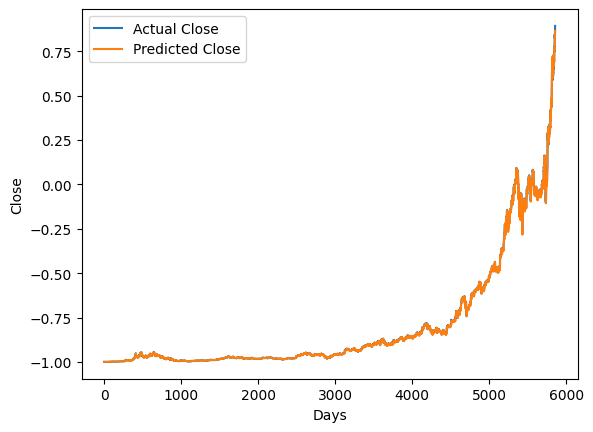

In [63]:
with torch.no_grad():
    predicted=model(X_train.to(device)).to('cpu').numpy()

plt.plot(y_train,label='Actual Close')
plt.plot(predicted,label='Predicted Close')
plt.xlabel('Days')
plt.ylabel('Close')
plt.legend()
plt.show()

In [65]:
train_prediction=predicted.flatten()

dummies=np.zeros((X_train.shape[0],lookback+1))
dummies[:,0]=train_prediction
dummies=scaler.inverse_transform(dummies)

train_prediction=dc(dummies[:,0])
train_prediction


array([1.06154872e-01, 1.10045558e-01, 1.08928376e-01, ...,
       1.70195682e+02, 1.71973636e+02, 1.74046394e+02])

In [70]:
dummies=np.zeros((X_train.shape[0],lookback+1))
dummies[:,0]=y_train.flatten().detach().cpu().numpy()
dummies=scaler.inverse_transform(dummies)

new_y_train=dc(dummies[:,0])
new_y_train

array([7.91646265e-02, 7.65634249e-02, 7.52572660e-02, ...,
       1.72548002e+02, 1.74955992e+02, 1.76572494e+02])

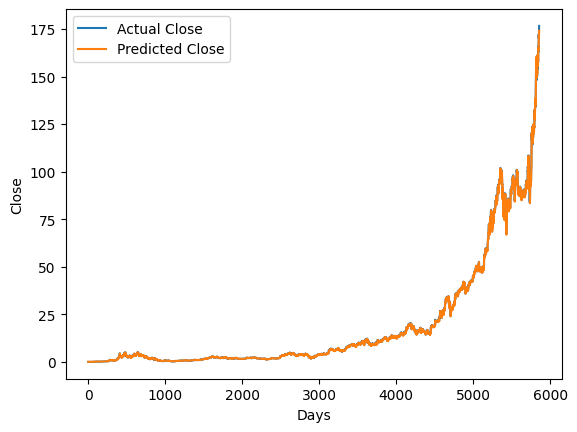

In [71]:

plt.plot(new_y_train,label='Actual Close')
plt.plot(train_prediction,label='Predicted Close')
plt.xlabel('Days')
plt.ylabel('Close')
plt.legend()
plt.show()

In [73]:
test_prediction=model(X_test.to(device)).detach().cpu().numpy().flatten()

dummies=np.zeros((X_test.shape[0],lookback+1))
dummies[:,0]=test_prediction
dummies=scaler.inverse_transform(dummies)

test_prediction=dc(dummies[:,0])
test_prediction

array([175.60184024, 170.03546334, 166.11633071, 159.57630405,
       163.22541194, 160.20280456, 157.15139499, 156.10608434,
       158.1120721 , 155.26479016, 151.79012951, 148.94290315,
       148.79561845, 155.70808938, 151.63528576, 151.66478272,
       154.84937048, 158.57390767, 158.08053531, 158.09690398,
       160.98701682, 157.6856529 , 160.04376443, 156.49287969,
       159.69956098, 160.13681297, 163.8771908 , 170.26395222,
       171.68080117, 169.03837497, 167.59389103, 164.82059327,
       161.71245749, 161.56012045, 160.25293883, 159.64960457,
       160.65504681, 160.94195712, 164.03637545, 159.76316814,
       160.88842128, 153.88555303, 151.37750557, 152.92992826,
       160.79399988, 165.34439079, 165.81242921, 159.20468794,
       153.46406944, 156.91778152, 156.46051474, 157.05193794,
       157.24159221, 157.45268417, 156.25660943, 156.52163741,
       155.8615436 , 155.69805697, 156.48118539, 159.29758641,
       160.22389764, 159.27686572, 161.16070817, 160.89

In [74]:
dummies=np.zeros((X_test.shape[0],lookback+1))
dummies[:,0]=y_test.flatten().detach().cpu().numpy()
dummies=scaler.inverse_transform(dummies)

new_y_test=dc(dummies[:,0])
new_y_test


array([168.39999674, 164.73100188, 157.49200233, 163.43049557,
       158.75549155, 155.81100359, 155.14849755, 157.80650317,
       153.9050009 , 150.4364931 , 147.74550002, 148.02350066,
       156.44949298, 149.99299379, 150.98950412, 154.7564998 ,
       158.7025004 , 157.24400444, 157.43649336, 161.06300192,
       156.25000082, 159.96000907, 154.99800025, 159.78450022,
       159.52749817, 164.33250669, 172.14649963, 172.18150469,
       168.18550321, 166.93249662, 163.63549582, 160.36050519,
       160.85049265, 159.24699637, 158.82000468, 160.2200014 ,
       160.35200682, 164.31649929, 158.13900677, 160.55050963,
       151.80749309, 150.2240005 , 152.42050404, 162.05800044,
       166.1000065 , 165.56849431, 157.18699477, 151.75100589,
       156.86950922, 155.51400528, 156.44050549, 156.55299635,
       156.78300259, 155.27299395, 155.85099984, 154.96999843,
       154.91949732, 155.90300164, 159.25349382, 159.76699769,
       158.40199492, 161.00399689, 160.17649797, 159.33

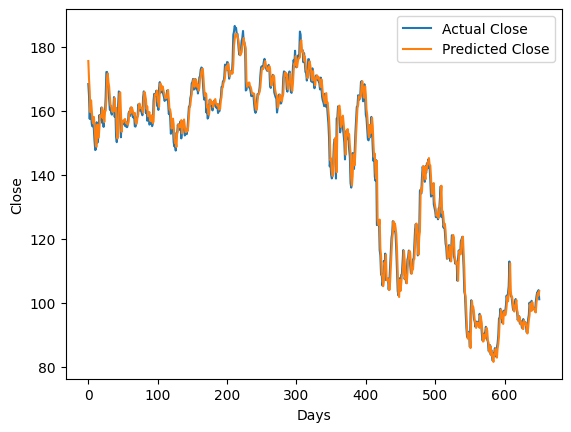

In [75]:

plt.plot(new_y_test,label='Actual Close')
plt.plot(test_prediction,label='Predicted Close')
plt.xlabel('Days')
plt.ylabel('Close')
plt.legend()
plt.show()